In [128]:
from src import *

from matplotlib import pyplot as plt
import geopandas as gpd
import matplotlib.colors as mcolors

#loading .env variables
from dotenv import load_dotenv
import os
from pathlib import Path
import pandas as pd

In [129]:
load_dotenv()

PROJECT_PATH = os.getenv('PROJECT_PATH')
LOCAL_DIR     = Path(os.getenv("PROJECT_PATH"), 'img','polrad')
REMOTE_DIR    = fix_path(os.getenv("REMOTE_DIR"))

polrad_folder = os.path.join(PROJECT_PATH, 'data', 'polrad')
polrad_img_folder = os.path.join(PROJECT_PATH, 'img', 'polrad')
df_polrad_processed_files = pd.read_csv(os.path.join(PROJECT_PATH, 'data', 'polrad_processed_files.txt'),sep='\t')

output_projection = "EPSG:4326"

In [130]:
clean_folder(polrad_folder)

In [ ]:
path = '/Oper/Polrad/Produkty/HVD/HVD_pas_250.max'
#path = '/Oper/Polrad/Produkty/HVD/HVD_pas_125.cappi'
path = '/Oper/Polrad/Produkty/HVD/HVD_pas_0_5.ppi'
df_files = get_list_of_files(path)
#radar_file = df_files.query("unit == 'RhoHV'").iloc[-1]
#radar_file = df_files.query("unit == 'KDP'").iloc[-1]

In [1]:
radars = ['brz', 'gdy', 'gsa', 'leg', 'pas', 'poz', 'ram', 'rze', 'swi', 'uzr']
radar_products = ['0_5.ppi', '125.cappi', '200.dprsi', '200.etz', '250.max']

compo_products = ['CAPPI.comp.cappi', 'CMAX_250.comp.cmax', 'DPSRI.comp.sri']

paths = []
for radar in radars:
    for product in radar_products:
        path = f'/Oper/Polrad/Produkty/HVD/HVD_{radar}_{product}'
        paths.append(path)

for compo_product in compo_products:
    path = f'/Oper/Polrad/Produkty/HVD/HVD_COMPO_{compo_product}'
    paths.append(path)


In [132]:
output_filename = polrad_folder + '/' + radar_file['filename']
download_file(radar_file['url'], output_filename)
radar_file_array = decode_h5_file(output_filename)

Processing dataset: dataset1
Processing dataset: dataset2
Processing dataset: dataset3


Text(-5, -5, '     2026-04-19     \n     18:45 UTC      \n                    \n      KDP MAX       ')

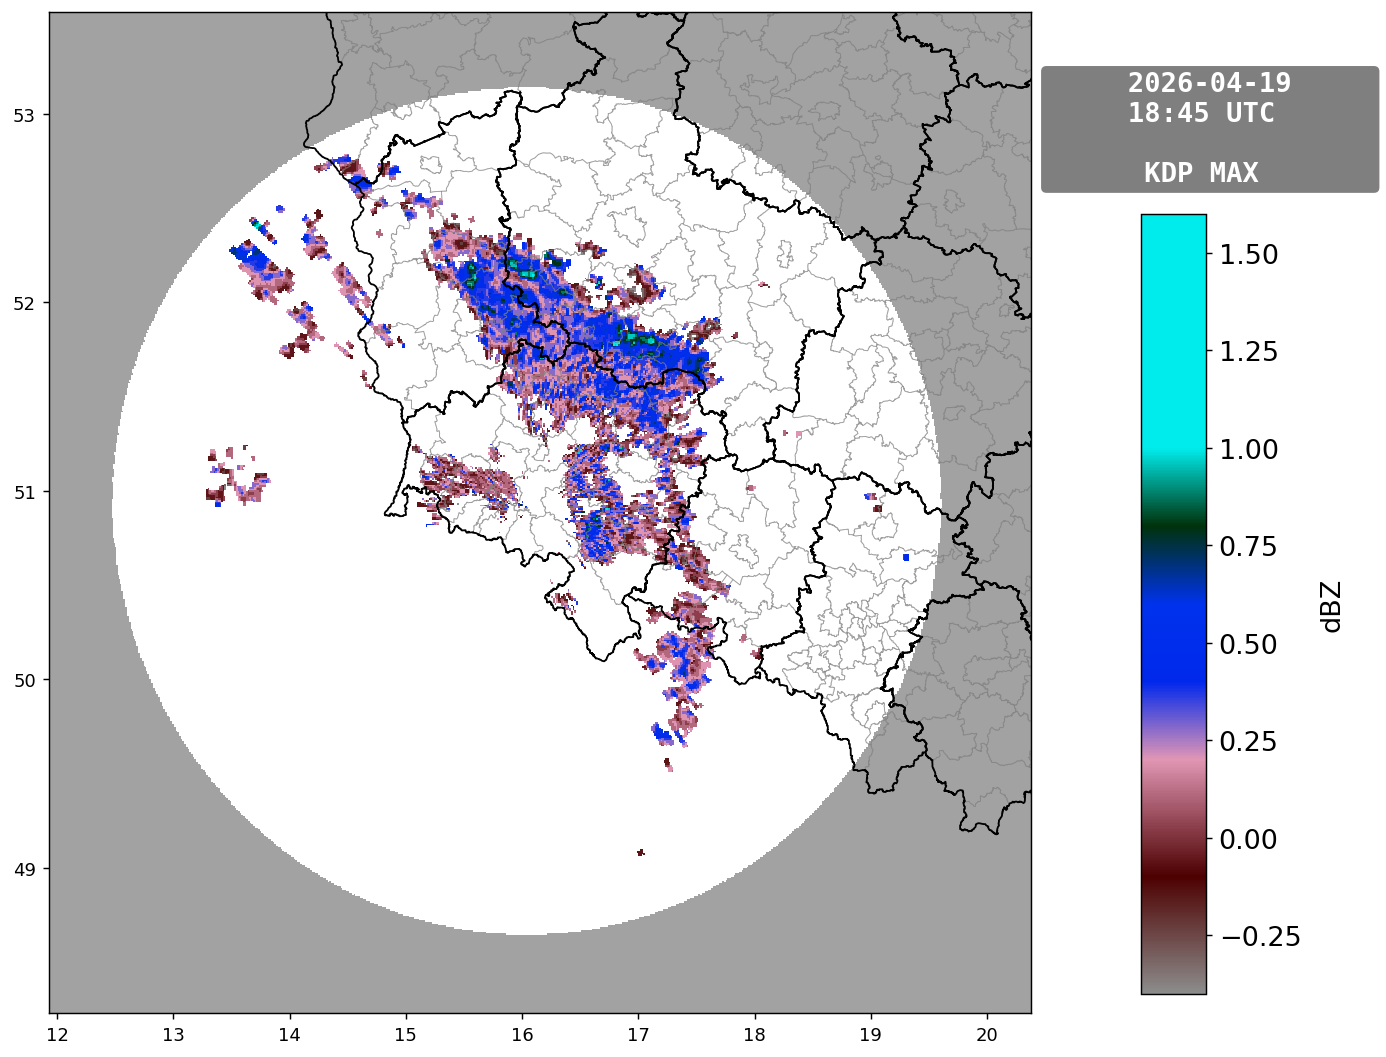

In [133]:
if radar_file_array['system']=='POLCOMP':
    lon_min, lon_max = 14.12, 24.15
    lat_min, lat_max = 49.00, 54.84
else:
    lon_min, lon_max = np.min(radar_file_array['lon_mesh']), np.max(radar_file_array['lon_mesh'])
    lat_min, lat_max = np.min(radar_file_array['lat_mesh']), np.max(radar_file_array['lat_mesh'])

scale = 3.0
bounds_padding_factor = 0.03
height = 10


dpi = 130
width_x = (lon_max - lon_min) * scale * dpi / 100 * 0.8
height_y = (lat_max - lat_min) * scale * dpi / 100

width = 10



fig, ax = plt.subplots(figsize=(width, height), dpi=dpi)

ax.set_facecolor("#A2A2A2FF")  # tło → szare

# Skopiuj cmap i ustaw kolory dla NaN i wartości poza zakresem
cmap, norm, label = color_palette(quantity=radar_file_array['quantity'],ctype='noaa',PROJECT_PATH=PROJECT_PATH)

#cmap, norm = load_pal_file(os.path.join(PROJECT_PATH, 'data', 'color_tables','SamBV.pal'))

label = 'dBZ'



data = radar_file_array['radar_data']['dataset1']

ax.pcolormesh(
    radar_file_array['lon_mesh'],
    radar_file_array['lat_mesh'],
    data,  # maskuj tylko NaN
    cmap=cmap,
    norm=norm,
    shading='flat'
)

#ax.grid(True, which='both', color='gray', linewidth=0.5, alpha=0.5, linestyle='--')

ax.set_xlim(lon_min* (1 - bounds_padding_factor), lon_max* (1 + bounds_padding_factor))
ax.set_ylim(lat_min* (1 - bounds_padding_factor*0.25), lat_max* (1 + bounds_padding_factor*0.25))

if radar_file_array['system']!='POLCOMP':
    gdf_shp_powiaty =  gpd.read_file(os.path.join(PROJECT_PATH, 'data', 'shapefiles', 'gadm41_POL.gpkg'), layer='ADM_ADM_2')
    gdf_shp_powiaty = gdf_shp_powiaty.to_crs(output_projection)
    gdf_shp_powiaty.plot(ax=ax, edgecolor="gray", facecolor="none",linewidth=0.5,alpha=0.5)

gdf_shp_wojewodztwa =  gpd.read_file(os.path.join(PROJECT_PATH, 'data', 'shapefiles', 'gadm41_POL.gpkg'), layer='ADM_ADM_1')
gdf_shp_wojewodztwa = gdf_shp_wojewodztwa.to_crs(output_projection)
gdf_shp_wojewodztwa.plot(ax=ax, edgecolor="black", facecolor="none",linewidth=1.0)


sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cax = fig.add_axes([0.975, 0.125, 0.05, 0.6])  
#             left bottom width height

cbar = plt.colorbar(sm, cax=cax)
cbar.set_label(label, rotation=90, labelpad=10, fontsize=15)
cbar.ax.tick_params(labelsize=15)

legend_text = (
    f"{radar_file_array['start_date'].strftime('%Y-%m-%d'):^20}\n"
    f"{(radar_file_array['start_date'].strftime('%H:%M')+" UTC"):^20}\n"
    f"{(" "):^20}\n"
    f"{(radar_file_array['quantity']+" "+radar_file_array['product']):^20}"
)

ax.annotate(
    legend_text,
    xy=(1.025, 0.95),
    xycoords="axes fraction",
    xytext=(-5, -5), textcoords="offset points",  # 🔑 do środka, nie na zewnątrz
    fontsize=15,
    color="white",
    fontweight="bold",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.2", fc="#00000080", ec="none"),
    ha="left",   # 🔑 kluczowe
    va="top",
    zorder=5,
)

#ax.title.set_text(f"{radar_file_array['start_date'].strftime('%Y-%m-%d %H:%M:%S')} UTC - {radar_file_array['quantity']} {radar_file_array['product']}")
#plt.close()

In [134]:
norm.vmax

1.6